# Used Car Listings — Exploratory Data Analysis

**Goal:** figure out what actually drives price in a real used-car listings dataset — mileage, model year, title status (clean vs. salvage), and brand — before building anything more complex on top of it (SQL + a dashboard, then a price-prediction model, in later phases of this project).

**Data source:** ~2,500 U.S. used-vehicle auction listings ("USA Cars" dataset). Each row is one listing with brand, model, year, mileage, title status, color, state, and price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Load the data and take a first look

In [2]:
df = pd.read_csv('../data/raw/us_cars.csv')
print(df.shape)
df.head()

(2499, 12)


,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,6300,toyota,cruiser,2008,clean vehicle,274117,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,2899,ford,se,2011,clean vehicle,190552,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,5350,dodge,mpv,2018,clean vehicle,39590,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,25000,ford,door,2014,clean vehicle,64146,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,27700,chevrolet,1500,2018,clean vehicle,6654,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


## 2. Check data quality before trusting anything

`df.isnull().sum()` shows zero missing values across every column — but that doesn't mean the data is clean. Missing values are the *obvious* kind of dirty data; real-world data usually has quieter problems too, so it's worth checking directly rather than trusting a clean `isnull()` result.

In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate VINs (same car listed twice):", df['vin'].duplicated().sum())
print("Listings priced at exactly $0:", (df['price'] == 0).sum())
print("Listings with 999,999 miles (looks like a placeholder, not a real odometer reading):", (df['mileage'] == 999999).sum())
print("\nBrands with 5 or fewer listings (long tail):")
print(df['brand'].value_counts()[df['brand'].value_counts() <= 5])

Missing values per column:
price           0
brand           0
model           0
year            0
title_status    0
mileage         0
color           0
vin             0
lot             0
state           0
country         0
condition       0
dtype: int64

Duplicate VINs (same car listed twice): 4
Listings priced at exactly $0: 43
Listings with 999,999 miles (looks like a placeholder, not a real odometer reading): 1

Brands with 5 or fewer listings (long tail):
brand
heartland          5
audi               4
land               4
peterbilt          4
acura              3
mazda              2
lincoln            2
lexus              2
toyota             1
jaguar             1
harley-davidson    1
maserati           1
ram                1
Name: count, dtype: int64


A few things stand out:
- **43 listings priced at \$0** — not a real sale price, almost certainly missing/placeholder data.
- **4 duplicate VINs** — the same vehicle listed more than once.
- **One listing with 999,999 miles** — a suspiciously round number that's a classic placeholder/sentinel value in scraped automotive data, not a believable odometer reading.
- A handful of brands are actually **commercial trucks (`peterbilt`) or a motorcycle (`harley-davidson`)** — not passenger vehicles, so they don't belong in a used-*car* price analysis.
- The `condition` column looked promising but turns out to hold values like `"2 days left"` — it's actually **time remaining on the auction listing**, not the vehicle's condition. Misleading name, so it gets dropped.
- The `model` column is inconsistent — some values are real model names (`f-150`, `durango`), others are body styles that leaked in (`door`, `doors`, `mpv`). I'm treating `model` as unreliable for this pass and analyzing by `brand` instead, which is clean.

## 3. Clean it up

In [4]:
before = len(df)

df_clean = (
    df
    .drop_duplicates(subset='vin', keep='first')
    .query('price > 0')
    .query('brand not in ["peterbilt", "harley-davidson"]')
    .query('mileage != 999999')
    .drop(columns=['vin', 'lot', 'condition'])
)

print(f"{before} rows -> {len(df_clean)} rows ({before - len(df_clean)} dropped)")
df_clean.head()

2499 rows -> 2448 rows (51 dropped)


,price,brand,model,year,title_status,mileage,color,state,country
0,6300,toyota,cruiser,2008,clean vehicle,274117,black,new jersey,usa
1,2899,ford,se,2011,clean vehicle,190552,silver,tennessee,usa
2,5350,dodge,mpv,2018,clean vehicle,39590,silver,georgia,usa
3,25000,ford,door,2014,clean vehicle,64146,blue,virginia,usa
4,27700,chevrolet,1500,2018,clean vehicle,6654,red,florida,usa


## 4. What does the price distribution look like?

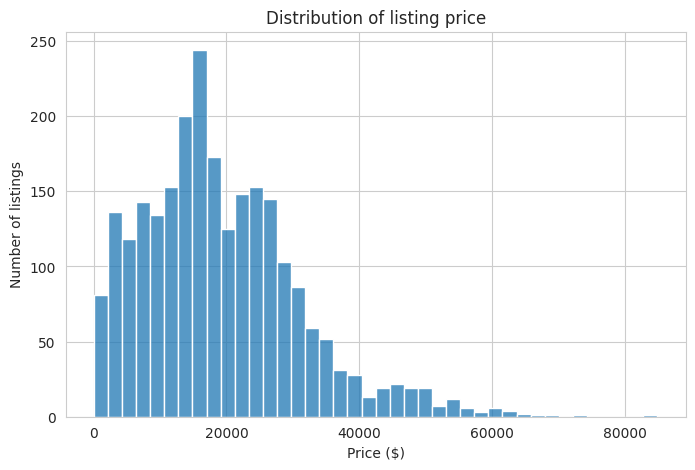

count     2448.0
mean     19123.0
std      11925.0
min         25.0
25%      10682.0
50%      17100.0
75%      25800.0
max      84900.0
Name: price, dtype: float64


In [5]:
fig, ax = plt.subplots()
sns.histplot(df_clean['price'], bins=40, ax=ax)
ax.set_title('Distribution of listing price')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Number of listings')
plt.show()

print(df_clean['price'].describe().round(0))

Median price is about \$17,100 and the mean is pulled up to about \$19,100 — the classic right-skew you get with price data, where a smaller number of expensive listings stretch the tail without there being nearly as many of them.

## 5. Does mileage actually predict price?

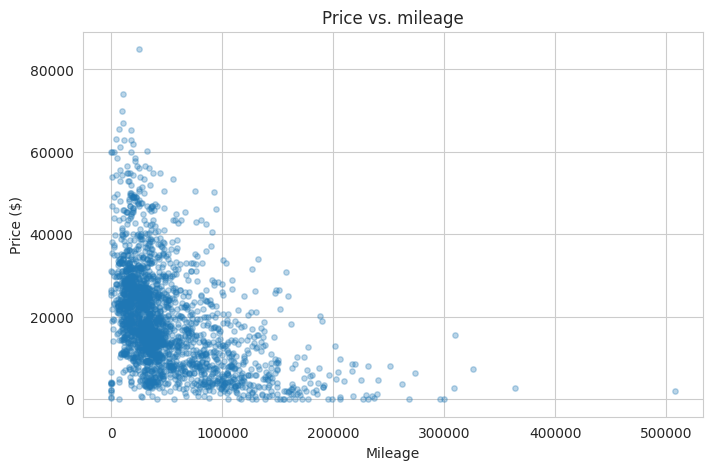

Correlation (mileage, price): -0.443


In [6]:
fig, ax = plt.subplots()
ax.scatter(df_clean['mileage'], df_clean['price'], alpha=0.3, s=15)
ax.set_title('Price vs. mileage')
ax.set_xlabel('Mileage')
ax.set_ylabel('Price ($)')
plt.show()

print("Correlation (mileage, price):", round(df_clean['mileage'].corr(df_clean['price']), 3))

A correlation around **-0.44** — a real, moderate relationship, but far from the whole story. Mileage alone doesn't determine price; brand, year, and title status clearly matter too, which is exactly the kind of thing a single scatter plot can't show and a regression model (phase 3 of this project) will actually quantify.

## 6. Does model year matter?

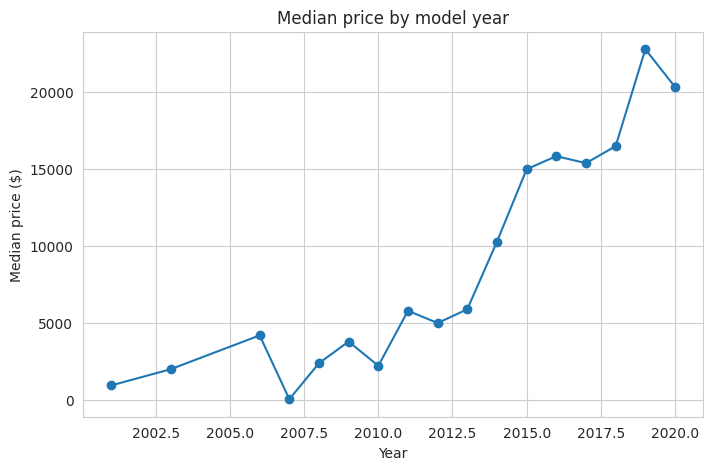

Correlation (year, price): 0.381


In [7]:
year_price = df_clean.groupby('year')['price'].agg(['median', 'count'])
year_price = year_price[year_price['count'] >= 5]  # drop years with too few listings to be meaningful

fig, ax = plt.subplots()
ax.plot(year_price.index, year_price['median'], marker='o')
ax.set_title('Median price by model year')
ax.set_xlabel('Year')
ax.set_ylabel('Median price ($)')
plt.show()

print("Correlation (year, price):", round(df_clean['year'].corr(df_clean['price']), 3))

## 7. How much does a salvage title actually cost you?

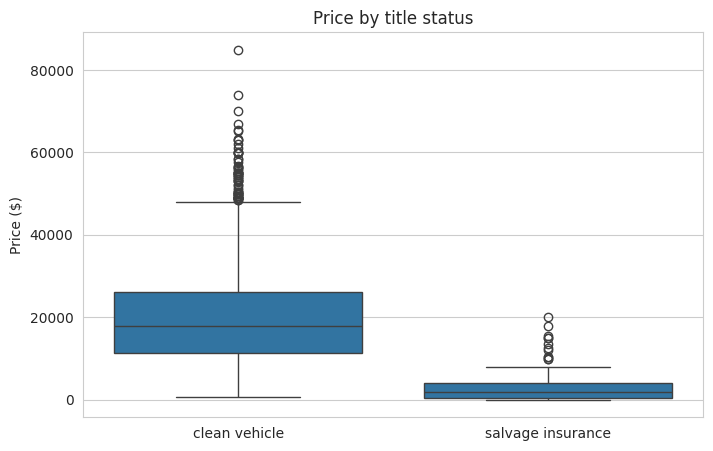

                    median          mean  count  pct_of_clean_median
title_status                                                        
clean vehicle      18000.0  19920.785500   2331                100.0
salvage insurance   1900.0   3235.940171    117                 10.6


In [8]:
fig, ax = plt.subplots()
sns.boxplot(data=df_clean, x='title_status', y='price', ax=ax)
ax.set_title('Price by title status')
ax.set_xlabel('')
ax.set_ylabel('Price ($)')
plt.show()

summary = df_clean.groupby('title_status')['price'].agg(['median', 'mean', 'count'])
summary['pct_of_clean_median'] = (summary['median'] / summary.loc['clean vehicle', 'median'] * 100).round(1)
print(summary)

This is the sharpest finding in the dataset. A salvage-insurance title isn't a modest discount — median price drops from **\$18,000 for a clean title to \$1,900 for salvage**, about a 90% haircut. That's a bigger effect than mileage or year, and it's the kind of thing that's easy to miss if you only look at continuous variables like mileage and skip the categorical ones.

## 8. Which brands show up most, and how do their prices compare?

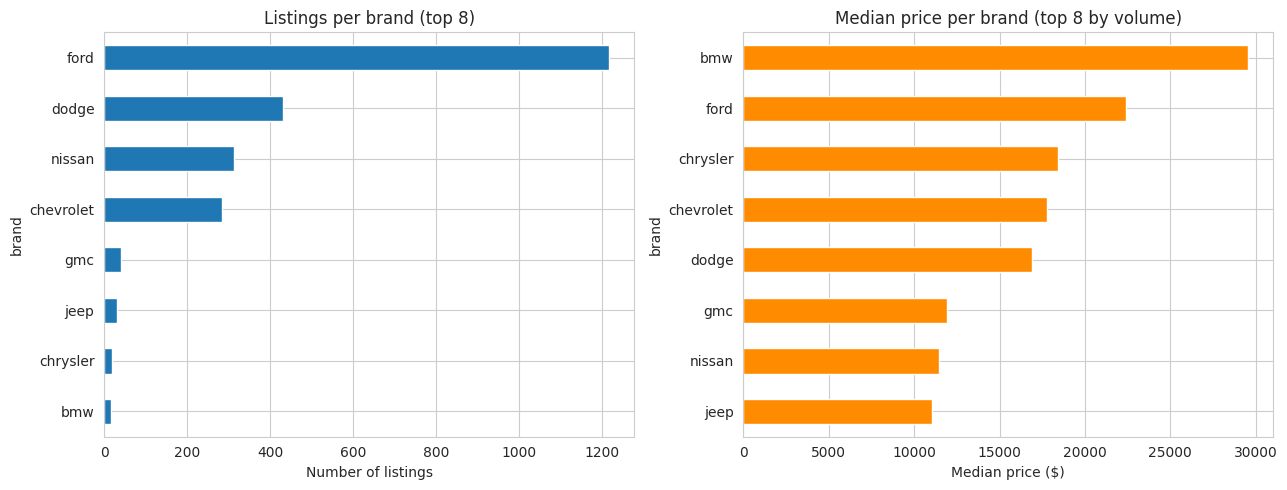

In [9]:
top_brands = df_clean['brand'].value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_brands.plot(kind='barh', ax=axes[0])
axes[0].set_title('Listings per brand (top 8)')
axes[0].set_xlabel('Number of listings')
axes[0].invert_yaxis()

brand_price = df_clean[df_clean['brand'].isin(top_brands.index)].groupby('brand')['price'].median().sort_values()
brand_price.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Median price per brand (top 8 by volume)')
axes[1].set_xlabel('Median price ($)')

plt.tight_layout()
plt.show()

## Key takeaways

- **Title status is the single biggest price driver found here** — salvage-insurance listings sell for roughly 90% less than clean-title listings.
- **Mileage and year both matter but only moderately on their own** (correlations of -0.44 and +0.38) — neither is a strong enough single predictor to price a car by itself.
- **Ford and Dodge dominate this dataset by volume**, but BMW commands the highest median price among high-volume brands — brand and price rank don't move together.
- **The data needed real cleaning before any of this was trustworthy**: \$0 placeholder prices, duplicate VINs, a mislabeled `condition` column, a messy `model` column, and a couple of non-passenger-vehicle brands all had to be handled first.

### Limitations / what I'd do next
- `model` is too inconsistent to use as-is; cleaning it (or sourcing a dataset with a reliable model field) would allow model-level questions, not just brand-level ones.
- ~2,500 listings is workable for exploration but small for anything statistically rigorous — a larger dataset would tighten confidence in these patterns.
- Next for this project: load this into a database and rebuild these questions as SQL queries + a dashboard (phase 2), then build a price-prediction model that combines mileage, year, title status, and brand together instead of one at a time (phase 3).